# Mini-Demo: Introduction to Video Object Tracking

**Objective:** Briefly introduce video as a sequence of images and demonstrate two conceptual approaches to tracking objects across frames: detection-based tracking and optical flow-based tracking. This is a "show and tell" demo due to time constraints, focusing on visual understanding rather than deep implementation details.

**Dataset:** A short sample video clip.
*   **Action:** Download a sample video. A general-purpose video is fine for demonstrating the techniques.
    *   You can use `wget` in your terminal:
        ```bash
        wget https://videos.pexels.com/video-files/3087697/3087697-sd_960_540_30fps.mp4 -O sample_video.mp4
        ```
    *   Or download it manually from a source like Pexels/Pixabay and save it as `sample_video.mp4` in the same directory as this notebook.
*   This sample video is a dash camera footage of traffic on the road at night, which is excellent for demonstrating object detection and tracking of vehicles. For a health context, if a short, simple clip of movement (e.g., hand motion, a person walking in a clinic hallway, instrument movement if clear) is available, that could be used. The current code assumes `sample_video.mp4`.

**Tools:** Python, OpenCV, Ultralytics YOLO (for detection-based part).

## 1. Setup and Imports

Ensure `ultralytics` and `opencv-python` are installed. If not, run in your terminal or a code cell:

In [33]:
%%bash
# pip install ultralytics opencv-python requests

(Requests might have been installed by ultralytics, but good to ensure).

We'll import the necessary libraries:
*   `cv2` (OpenCV) for video processing, drawing, and display.
*   `numpy` for numerical operations (though minimally used directly here).
*   `matplotlib.pyplot` for an optional helper function (though `cv2.imshow` is primary for video).
*   `ultralytics.YOLO` for the pre-trained object detector.
*   `time` for potential small delays if needed for smoother visualization in some environments (not strictly used in current `cv2.waitKey`).

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# Helper function to display a frame using Matplotlib
def show_frame(frame_bgr, title='Frame'):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(frame_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Helper function to create a video writer
def create_video_writer(filename, fps, width, height):
    # Try H.264 codec first (widely compatible)
    fourcc = cv2.VideoWriter_fourcc(*'avc1')
    out = cv2.VideoWriter(filename, fourcc, fps, (width, height))
    
    # If that fails, try MP4V codec
    if not out.isOpened():
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(filename, fourcc, fps, (width, height))
    
    return out

## 2. Approach 1: Detection-based Tracking (e.g., YOLO frame-by-frame)

**Concept:**
This approach involves running an object detector (like YOLO) on each frame of the video independently. Once objects are detected in each frame (with bounding boxes and class labels), a subsequent step (which we won't implement in detail here) would be to *associate* these detections across frames to form individual object tracks. This association can be done using various techniques, such as:
*   **IoU (Intersection over Union) Matching:** Comparing bounding boxes in consecutive frames.
*   **Kalman Filters:** Predicting an object's next position and matching detections to predictions.
*   **More Advanced Trackers:** Algorithms like SORT (Simple Online and Realtime Tracking) or DeepSORT (which adds appearance information using deep learning).

For this mini-demo, we will focus only on the **frame-by-frame detection part** to visualize how a detector sees objects in a video sequence.

YOLO model loaded successfully.
Video file found at: sample_video.mp4
Video properties: 960x540 at 29.97002997002997 fps, 299 frames

Starting Detection-based Tracking Demo (YOLO frame-by-frame)...
First frame shape: (540, 960, 3)
Frame 0: Detected 3 objects
  Detection 1: car (confidence: 0.84)
  Detection 2: car (confidence: 0.51)
  Detection 3: car (confidence: 0.42)


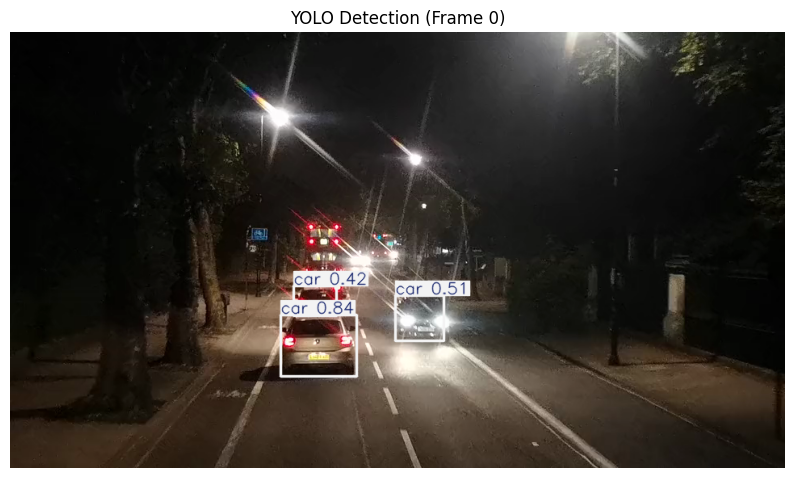

Frame 1: Detected 3 objects
  Detection 1: car (confidence: 0.85)
  Detection 2: car (confidence: 0.56)
  Detection 3: car (confidence: 0.43)


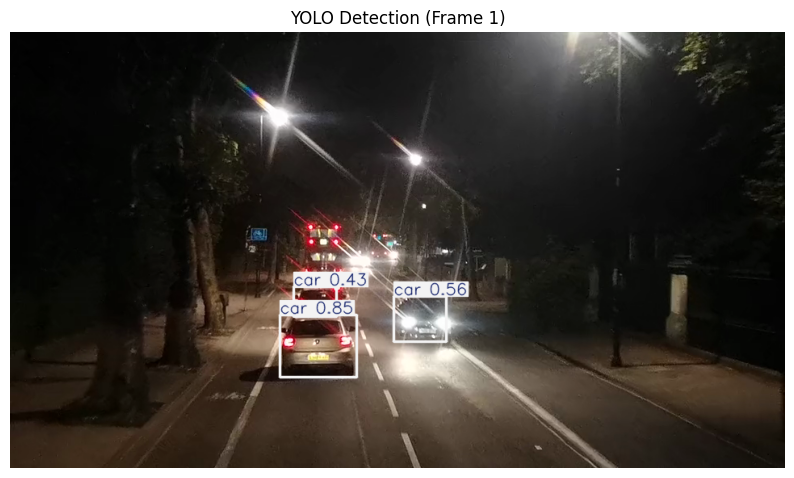

Frame 2: Detected 3 objects
  Detection 1: car (confidence: 0.81)
  Detection 2: car (confidence: 0.57)
  Detection 3: car (confidence: 0.41)


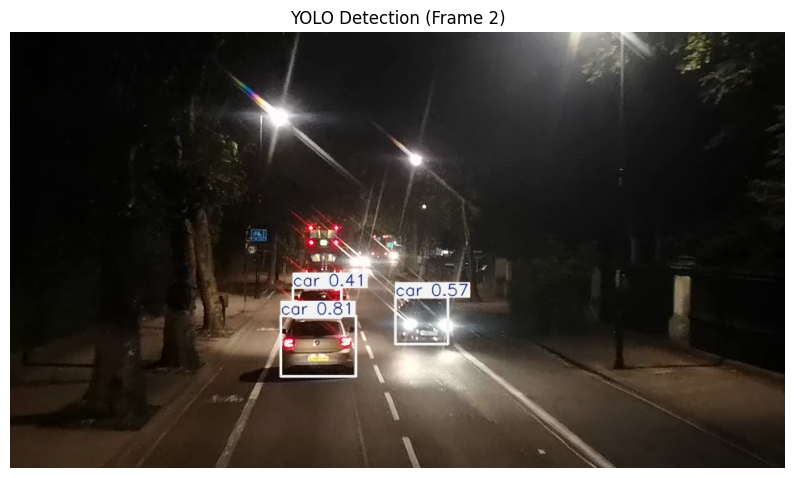

Processed 10 frames...
Processed 20 frames...
Processed 30 frames...
Processed 40 frames...
Processed 50 frames...
Processed 60 frames...
Processed 70 frames...
Processed 80 frames...
Processed 90 frames...
Processed 100 frames...
Detection-based Tracking Demo (YOLO) finished. Output saved to:

/Users/cseaman/datasci_223/lectures/08/demo/yolo_detection_output.mp4

You can open this video file directly to view the results.


In [35]:
# --- Load Pre-trained YOLO Model and Process Video ---
try:
    # Load YOLO model
    yolo_model = YOLO('yolov8n.pt')  # Nano model for speed
    print("YOLO model loaded successfully.")
    
    # Set up video
    video_path = 'sample_video.mp4'
    if not os.path.exists(video_path):
        print(f"ERROR: Video file '{video_path}' not found! Please download it using the command above.")
    else:
        print(f"Video file found at: {video_path}")
        
        # Open video
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file '{video_path}'.")
        else:
            # Get video properties
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            print(f"Video properties: {width}x{height} at {fps} fps, {frame_count} frames")
            
            # Create output video writer
            output_path = 'yolo_detection_output.mp4'
            out = create_video_writer(output_path, fps, width, height)
            
            print("\nStarting Detection-based Tracking Demo (YOLO frame-by-frame)...")
            
            # Process video frames
            frame_count = 0
            max_frames = 100  # Limit frames for a quick demo
            
            while cap.isOpened() and frame_count < max_frames:
                ret, frame = cap.read()
                if not ret:
                    break
                
                # Print frame info for first frame
                if frame_count == 0:
                    print(f"First frame shape: {frame.shape}")
                
                # Run YOLO detection
                results = yolo_model(frame, verbose=False)
                
                # Draw bounding boxes on frame
                annotated_frame = results[0].plot()
                
                # Print detection info for first few frames
                if frame_count < 3:
                    num_detections = len(results[0].boxes)
                    print(f"Frame {frame_count}: Detected {num_detections} objects")
                    if num_detections > 0:
                        for i, box in enumerate(results[0].boxes):
                            class_id = int(box.cls.cpu().numpy()[0])
                            class_name = yolo_model.names[class_id]
                            conf = float(box.conf.cpu().numpy()[0])
                            print(f"  Detection {i+1}: {class_name} (confidence: {conf:.2f})")
                    
                    # Display frame in notebook
                    show_frame(annotated_frame, f"YOLO Detection (Frame {frame_count})")
                
                # Write frame to video
                out.write(annotated_frame)
                
                frame_count += 1
                if frame_count % 10 == 0:
                    print(f"Processed {frame_count} frames...")
            
            # Release resources
            cap.release()
            out.release()
            
            # Get absolute path to output video
            abs_output_path = os.path.abspath(output_path)
            print(f"Detection-based Tracking Demo (YOLO) finished. Output saved to:")
            print(f"\n{abs_output_path}\n")
            print("You can open this video file directly to view the results.")
except Exception as e:
    print(f"Error in YOLO demo: {e}")

**Expected Visual Output (Approach 1):**
A video file (`yolo_detection_output.mp4`) will be created in your working directory.
*   You can open this video file with any standard video player.
*   In each frame, objects that YOLO can detect (based on its COCO training, e.g., 'car', 'truck', 'traffic light' in the dash camera footage) will be enclosed in bounding boxes.
*   Each box will have a label (the object class) and a confidence score.
*   You'll observe how detections might vary slightly frame-to-frame (e.g., confidence scores changing, occasional missed detections or new detections). This highlights why a separate tracking algorithm is needed to link these detections into smooth tracks.
*   The video is saved with a widely compatible H.264 codec, ensuring it can be played on most devices and platforms.

## 3. Approach 2: Optical Flow-based Tracking (Lucas-Kanade)

**Concept:**
Optical flow estimates the motion of image pixels or features between consecutive frames. The Lucas-Kanade method is a popular technique for tracking a sparse set of feature points (like corners).
Unlike detection-based methods, optical flow doesn't inherently identify *what* the objects are. Instead, it tracks the movement of salient points. This can be useful for understanding motion patterns or for tracking objects once they've been initially identified by other means.

We will:
1.  Detect good features to track (e.g., corners using Shi-Tomasi algorithm) in the first frame.
2.  For each subsequent frame, calculate the new positions of these features using Lucas-Kanade optical flow.
3.  Draw lines (tracks) showing the movement of these points.

Video properties for optical flow: 960x540 at 29.97002997002997 fps

Starting Optical Flow-based Tracking Demo (Lucas-Kanade)...


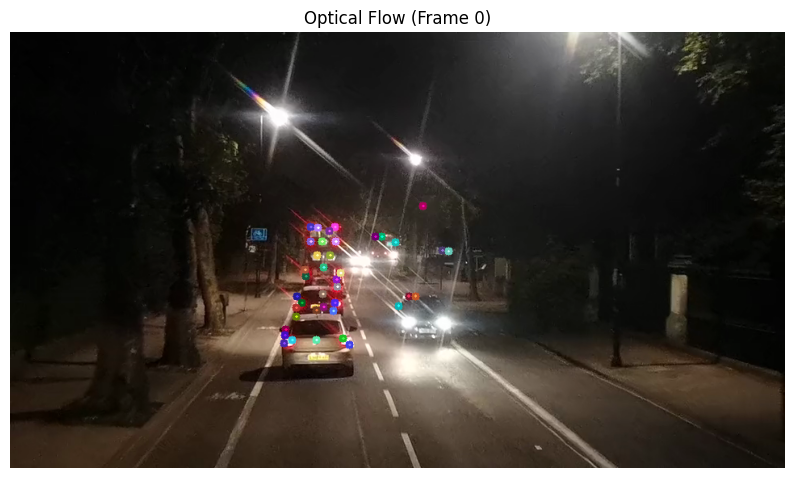

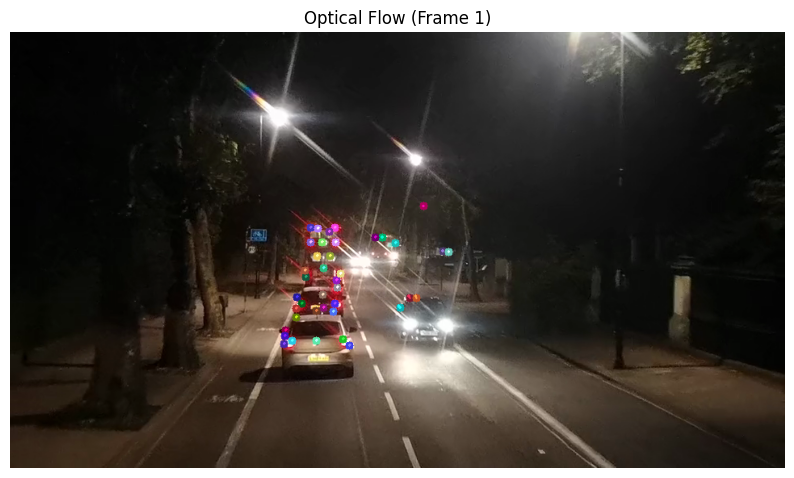

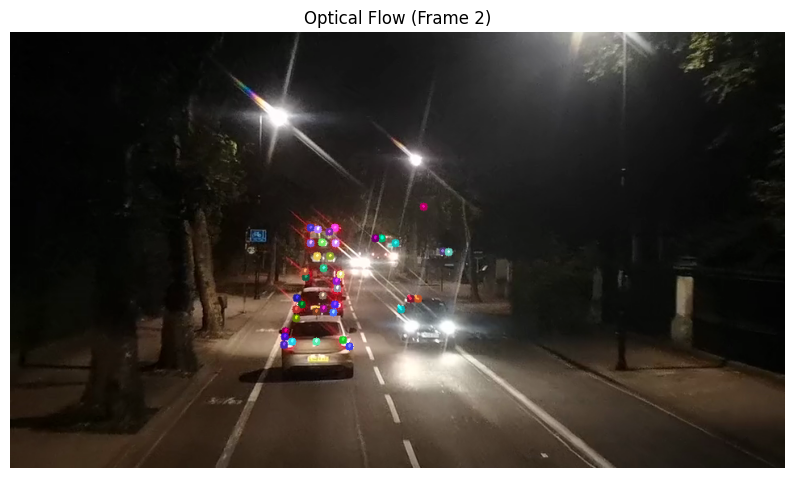

Processed 10 frames...
Processed 20 frames...
Processed 30 frames...
Processed 40 frames...
Processed 50 frames...
Processed 60 frames...
Processed 70 frames...
Processed 80 frames...
Processed 90 frames...
Processed 100 frames...
Optical Flow-based Tracking Demo finished. Output saved to:

/Users/cseaman/datasci_223/lectures/08/demo/optical_flow_output.mp4

You can open this video file directly to view the results.


In [36]:
# --- Optical Flow Tracking Demo ---
try:
    # Set up video
    video_path = 'sample_video.mp4'  # Use the same video file
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video file '{video_path}' for Optical Flow demo.")
    else:
        # Get video properties
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        print(f"Video properties for optical flow: {width}x{height} at {fps} fps")
        
        # Create output video writer
        output_path = 'optical_flow_output.mp4'
        out = create_video_writer(output_path, fps, width, height)
        
        print("\nStarting Optical Flow-based Tracking Demo (Lucas-Kanade)...")
        
        # Parameters for feature detection and optical flow
        feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
        lk_params = dict(winSize=(15, 15), maxLevel=2,
                         criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
        
        # Create random colors for visualization
        track_colors = np.random.randint(0, 255, (100, 3))
        
        # Read first frame
        ret, old_frame = cap.read()
        if not ret:
            print("Error: Could not read the first frame for Optical Flow.")
        else:
            # Convert to grayscale and find corners
            old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
            
            # Create mask for drawing tracks
            mask = np.zeros_like(old_frame)
            
            # Process video frames
            frame_count = 0
            max_frames = 100  # Limit frames for a quick demo
            
            while cap.isOpened() and frame_count < max_frames:
                ret, frame = cap.read()
                if not ret:
                    break
                
                # Convert to grayscale
                frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                
                if p0 is not None and len(p0) > 0:
                    # Calculate optical flow
                    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
                    
                    # Select good points
                    if p1 is not None and st is not None:
                        good_new = p1[st == 1]
                        good_old = p0[st == 1]
                        
                        # Draw tracks
                        for i, (new, old) in enumerate(zip(good_new, good_old)):
                            a, b = new.ravel().astype(int)
                            c, d = old.ravel().astype(int)
                            mask = cv2.line(mask, (a, b), (c, d), track_colors[i % 100].tolist(), 2)
                            frame = cv2.circle(frame, (a, b), 5, track_colors[i % 100].tolist(), -1)
                        
                        # Update points for next frame
                        p0 = good_new.reshape(-1, 1, 2)
                    else:
                        # If no good points, reset tracking
                        p0 = None
                
                if p0 is None or len(p0) == 0:
                    # Re-detect features if none are being tracked
                    p0 = cv2.goodFeaturesToTrack(frame_gray, mask=None, **feature_params)
                    mask = np.zeros_like(old_frame)  # Reset mask
                
                # Combine frame and mask
                result = cv2.add(frame, mask)
                
                # Display first few frames in notebook
                if frame_count < 3:
                    show_frame(result, f"Optical Flow (Frame {frame_count})")
                
                # Write to video
                out.write(result)
                
                # Update for next frame
                old_gray = frame_gray.copy()
                
                frame_count += 1
                if frame_count % 10 == 0:
                    print(f"Processed {frame_count} frames...")
            
            # Release resources
            cap.release()
            out.release()
            
            # Get absolute path to output video
            abs_output_path = os.path.abspath(output_path)
            print(f"Optical Flow-based Tracking Demo finished. Output saved to:")
            print(f"\n{abs_output_path}\n")
            print("You can open this video file directly to view the results.")
except Exception as e:
    print(f"Error in Optical Flow demo: {e}")

**Expected Visual Output (Approach 2):**
A video file (`optical_flow_output.mp4`) will be created in your working directory.
*   You can open this video file with any standard video player.
*   Initially, salient feature points (corners) will be detected in the first frame.
*   In subsequent frames, these points will be tracked. Small circles will indicate their current positions.
*   Lines (tracks) will be drawn on a mask and overlaid on the video, showing the path these points have taken over time.
*   If points are lost (e.g., go out of frame or become occluded), they will disappear. If all points are lost, the code attempts to re-detect new features.
*   This demo visually shows how groups of pixels that move together can be tracked.
*   The video is saved with a widely compatible H.264 codec, ensuring it can be played on most devices and platforms.

**Self-Check / Validation:**
*   Were you able to download/provide a sample video file and did it load correctly for both demos?
*   **For Approach 1 (YOLO Detection-based):**
    *   Was the video with YOLO detections created successfully?
    *   Can you open and play the video file (`yolo_detection_output.mp4`) in a video player?
    *   Are objects properly detected and labeled with bounding boxes?
*   **For Approach 2 (Optical Flow-based):**
    *   Was the video with optical flow tracking created successfully?
    *   Can you open and play the video file (`optical_flow_output.mp4`) in a video player?
    *   Are feature points properly tracked with colored lines showing their paths?
*   **Note on Video Playback:** If you have issues with the video files, check that you have a compatible video player installed. Most modern video players (VLC, QuickTime, Windows Media Player, etc.) should be able to play the H.264 encoded MP4 files.